### Proyecto de Riesgo Crediticio

#### 1. Definición del problema

##### Objetivo del negocio

El objetivo del negocio es estimar la probabilidad de incumplimiento de un solicitante para apoyar la toma de decisiones en la aprobación de créditos.

##### Variable objetivo (loan_status)

La variable objetivo a predecir es 'loan_status'. Esta indica si el solicitante incumplió (default) o no con el pago del préstamo. Esta será la variable que el modelo intentará predecir.

##### Por qué predecir el incumplimiento

Predecir el incumplimiento permite a las entidades financieras evaluar el riesgo de cada solicitante antes de aprobar un préstamo. Esto facilita decisiones más informadas sobre la aprobación del crédito, las tasas de interés y los límites de financiamiento, reduciendo potenciales pérdidas por impago.

#### 2. Carga e inspección de los datos

In [1]:
import pandas as pd
import statistics as stat
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Carga del dataset
df = pd.read_csv('../data/credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
# Tamaño del dataset
df.shape

(32581, 12)

In [4]:
# Variable target
print(df['loan_status'].value_counts())

loan_status
0    25473
1     7108
Name: count, dtype: int64


Se observa un notorio desbalance de datos. En el negocio, implica que la cartera está compuesta por clientes que en su mayoría cumplen en pagar, sin embargo, para el modelo implicará ajustar la diferencia entre la cantidad de estos, lo cuál se hará posteriormente.

In [5]:
# Verificamos el tipo de dato de cada variable
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB


In [6]:
# Duplicados y vacíos
print('Duplicated values:',df.duplicated().sum())
print('Missing values: \n',df.isnull().sum())

Duplicated values: 165
Missing values: 
 person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


Según lo observado, hay unos cuantos valores duplicados, qué en relación a la base son una cantidad mínima, y una gran cantidad de valores vacíos.

Por un lado, estos valores duplicados pueden representar registros con información inválido de los clientes, por lo que se va a tener que hacer una evaluación posteriormente para evaluar qué hacer con ellos.

Por otro lado, los valores faltantes que hay pueden indicar que algunos clientes todavía no crean un historial crediticio con el banco, o que directamente que se les ofreció cuotas sin intereses, por lo que habrá que analizarlo en la etapa de preprocesamiento.

#### 3. EDA

##### 3.1 Análisis univariado

In [7]:
# Variables numéricas
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


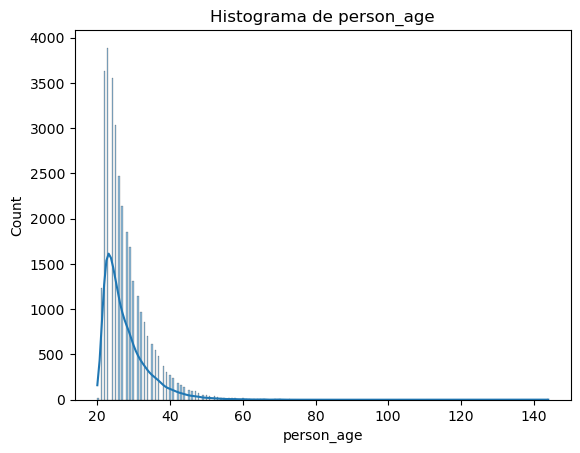

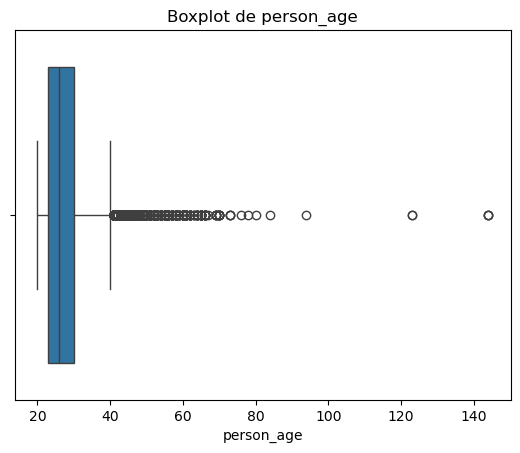

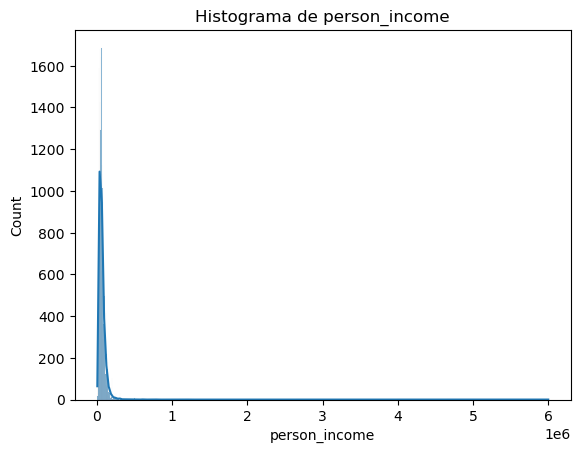

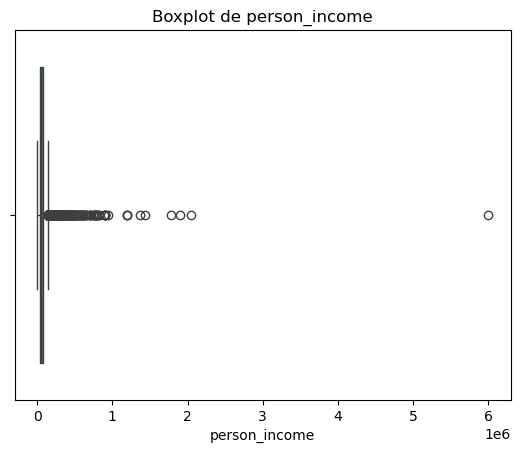

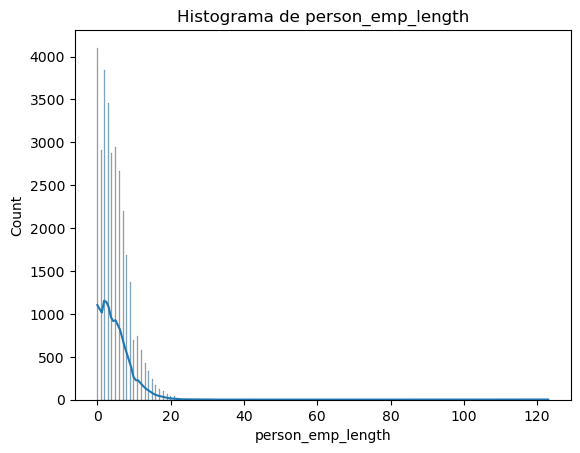

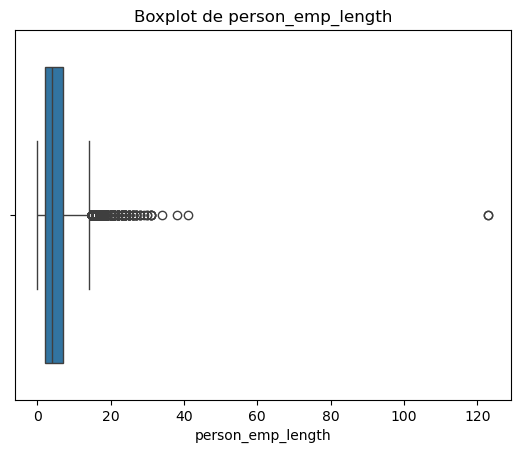

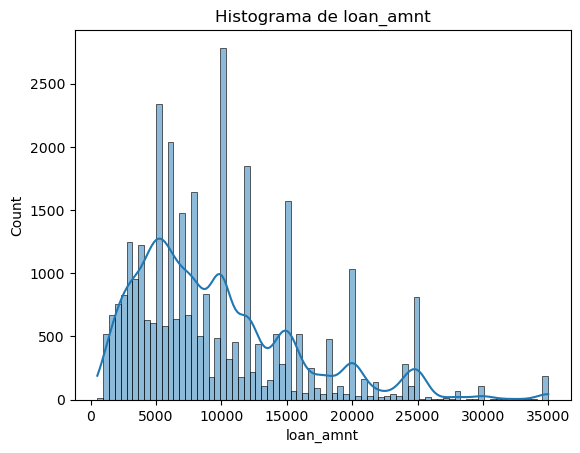

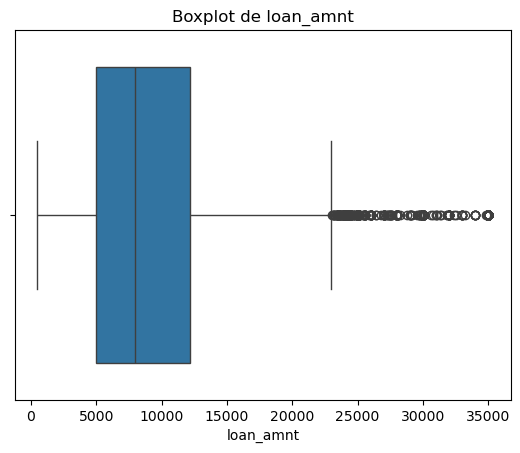

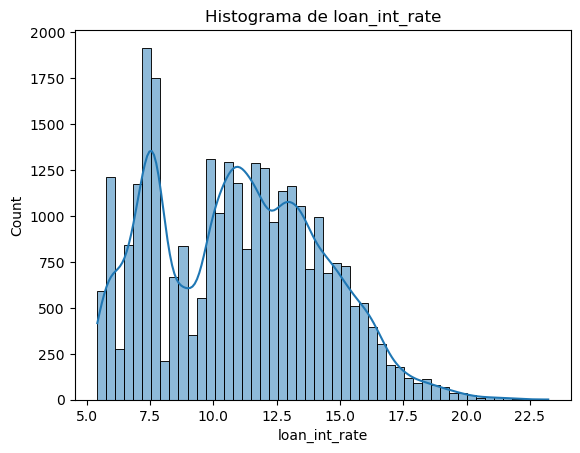

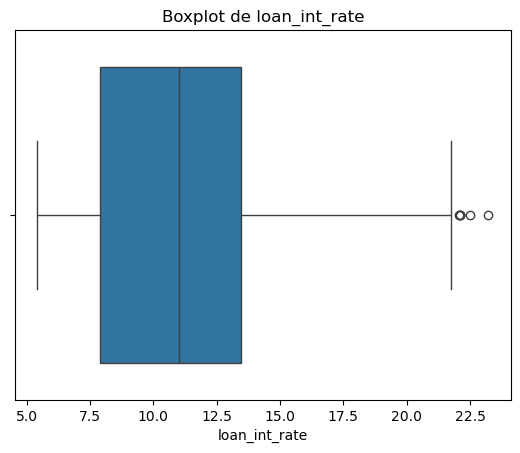

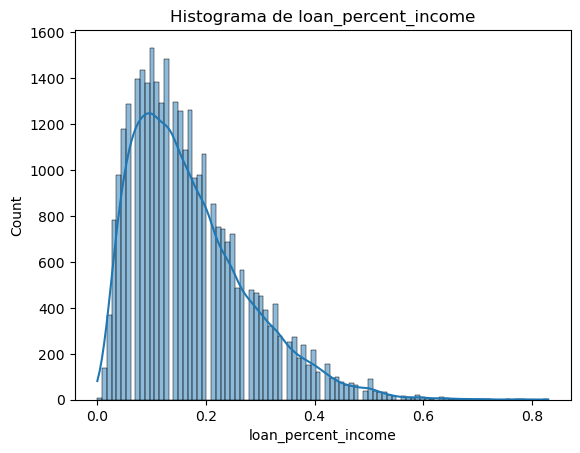

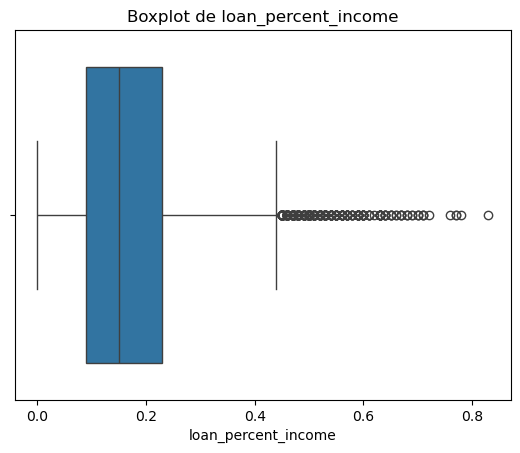

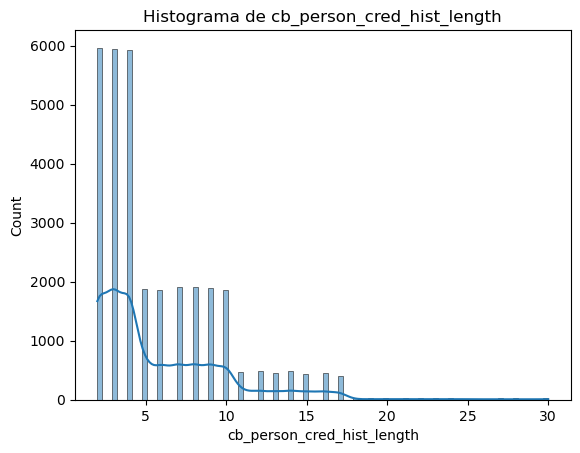

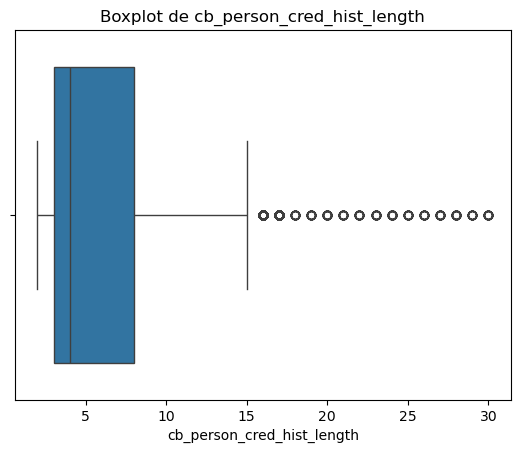

In [8]:
df_numerical = df.select_dtypes(include=['number'])
df_numerical = df_numerical.drop(columns='loan_status')

for columns in df_numerical.columns:
    
    # Histograma
    sns.histplot(df_numerical[columns], kde=True)
    plt.title(f'Histograma de {columns}')
    plt.show()
    
    # Boxplot
    sns.boxplot(x=df_numerical[columns])
    plt.title(f'Boxplot de {columns}')
    plt.show()

##### Comentarios 

* **person_age** 

  Según lo revisado, el rango de edad está entre los 23 y 30 años principalmente, que es lo que se visualiza según la distribución. Sin embargo, notamos una asimetría positiva donde se pueden observar edades muy poco realistas de hasta casi 150 años. Para el negocio, trabajar con un rango de edad tan grande puede dar unos resultados inexactos, por ello es que estos outliers pasarán a ser evaluados en la limpieza de datos.

* **person_income**

  Según lo revisado, la mayoría de personas perciben un ingreso similar que no supera el millón de dólares anuales. Sin embargo, existen ingresos extremadamente altos. En este caso, la media es significativamente mayor que la mediana.

* **person_emp_length**

  Según lo revisado, la mayoría de personas no pasan de los 20 años de experiencia. Aunque existen valores imposibles, la distribución se concentra en el primer grupo antes mencionado.

* **loan_amount**

  Según lo revisado, los préstamos varían, no hay una tendencia para una cantidad en específico, aunque sí se observa que hay una gran cantidad de préstamos altos, que representan outliers en la distribución, ya que está sesgada a la derecha.

* **loan_int_rate**

  Según lo revisado, no se presenta una alta concentración de tasas en un rango en específico, solo ligeramente en un 7.5%. Lo que sí se puede observar es que hay tasas extraordinariamente altas pero tampoco improbables, además de que la distribución es relativamente uniforme.

* **loan_percent_income**

  Según lo revisado, la mayoría de personas sacaron un préstamo que tiende a ser no mayor a la mitad de sus ingresos anuales, lo cual es correcto porque reduce el riesgo de impago. Sin embargo, sí hay un grupo que incluso llega hasta el 80% de sus ingresos.

* **cb_person_cred_hist_length**

  Según lo revisado, las personas no cuentan un historial crediticio mayor a 15 años, solo algunas y son muy pocas. Esto quiere indicar que la gran mayoría en el dataset son jóvenes. Igualmente, habría que validarlo porque a simple vista no coincide con las edades observadas.

person_age

Según lo revisado, la mayoría de edad se concentra entre los 20 y 40 años. La distribución presenta una asimetría positiva donde se pueden observar edades muy poco realistas. Sin embargo, se puede observar que tanto la media como la mediana son parecidas.

person_income

Según lo revisado, la mayoría de personas perciben un ingreso similar que no supera el millón de dólares anuales. Sin embargo, existen ingresos extremadamente altos. En este caso, la media es significativamente mayor que la mediana.

person_emp_length

Según lo revisado, la mayoría de personas no pasan de los 20 años de experiencia. Aunque existen valores imposibles, la distribución se concentra en el primer grupo antes mencionado.

loan_amount

Según lo revisado, los préstamos varían, no hay una tendencia para una cantidad en específico, aunque sí se observa que hay una gran cantidad de préstamos altos, que representan outliers en la distribución, ya que está sesgada a la derecha.

loan_int_rate

Según lo revisado, no se presenta una alta concentración de tasas en un rango en específico, solo ligeramente en un 7.5%. Lo que sí se puede observar es que hay tasas extraordinariamente altas pero tampoco improbables, además de que la distribución es relativamente uniforme.

loan_percent_income

Según lo revisado, la mayoría de personas sacaron un préstamo que tiende a ser no mayor a la mitad de sus ingresos anuales, lo cual es correcto porque reduce el riesgo de impago. Sin embargo, sí hay un grupo que incluso llega hasta el 80% de sus ingresos.

cb_person_cred_hist_length

Según lo revisado, las personas no cuentan un historial crediticio mayor a 15 años, solo algunas y son muy pocas. Esto quiere indicar que la gran mayoría en el dataset son jóvenes. Igualmente, habría que validarlo porque a simple vista no coincide con las edades observadas.

                       Absolute  Relative
person_home_ownership                    
RENT                      16446     50.48
MORTGAGE                  13444     41.26
OWN                        2584      7.93
OTHER                       107      0.33


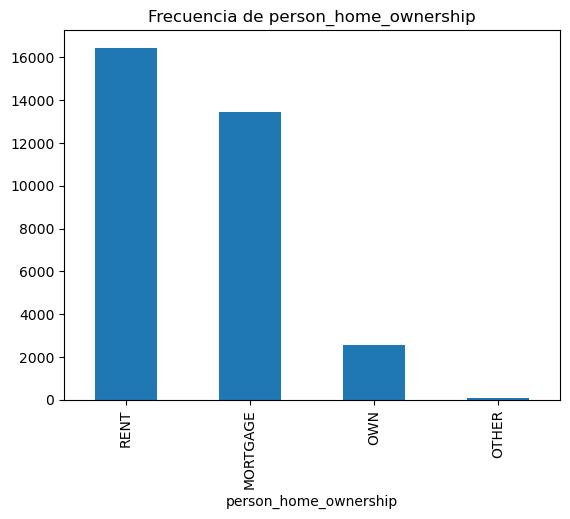

                   Absolute  Relative
loan_intent                          
EDUCATION              6453     19.81
MEDICAL                6071     18.63
VENTURE                5719     17.55
PERSONAL               5521     16.95
DEBTCONSOLIDATION      5212     16.00
HOMEIMPROVEMENT        3605     11.06


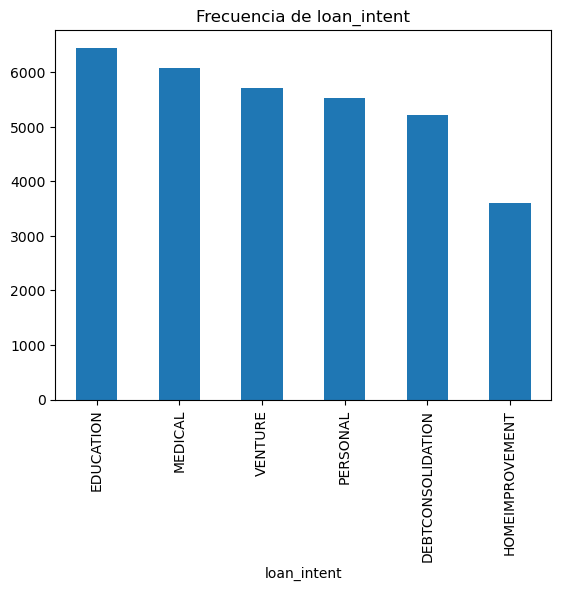

            Absolute  Relative
loan_grade                    
A              10777     33.08
B              10451     32.08
C               6458     19.82
D               3626     11.13
E                964      2.96
F                241      0.74
G                 64      0.20


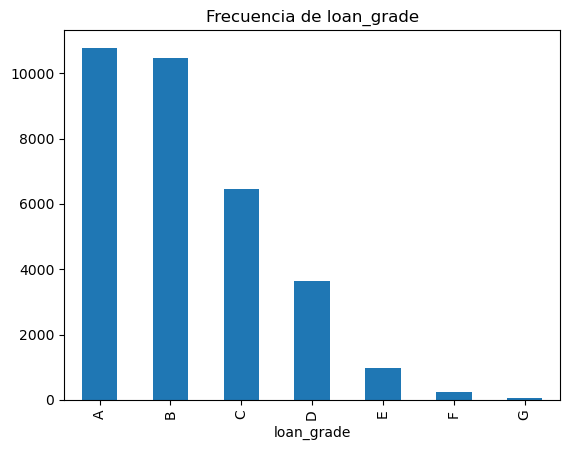

                           Absolute  Relative
cb_person_default_on_file                    
N                             26836     82.37
Y                              5745     17.63


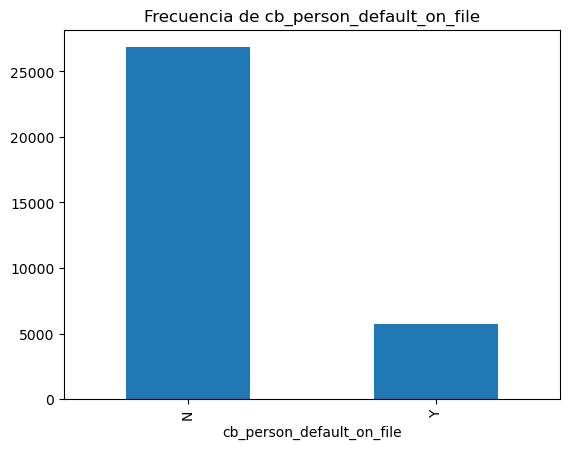

             Absolute  Relative
loan_status                    
0               25473     78.18
1                7108     21.82


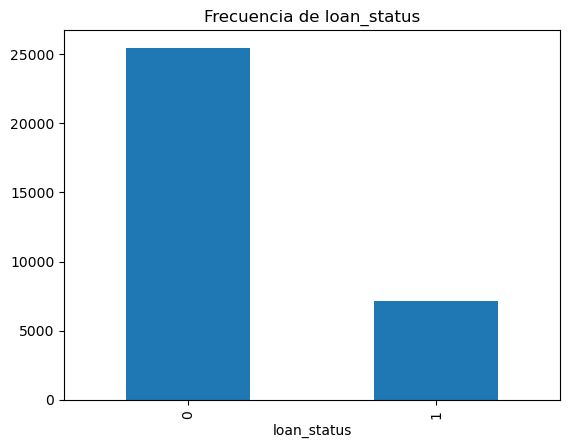

In [9]:
# Variables categóricas
df_categorical = list(df.select_dtypes(include=['object']).columns)
df_categorical.append('loan_status')

for columns in df_categorical:
    
    # Frecuencia relativa y absoluta
    fa = df[columns].value_counts()
    fr = (df[columns].value_counts(normalize=True)*100).round(2)
    frequency_table = pd.DataFrame({'Absolute': fa, 'Relative': fr})
    print(frequency_table)

    # Barplot
    fa.plot(kind='bar', title=f"Frecuencia de {columns}")
    plt.show()

person_home_ownership

Según lo observado, las categorías dominantes son la de RENT y MORTGAGE. Esto tiene sentido ya que estos dos casos tienden a generar más deuda por pagar, que los que tienen su propia casa u otros casos.

loan_intent

Según lo observado, si bien el motivo con mayor número de deudores, no es el principal, ya que no hay una gran distribución entre los demás. Esto quiere decir que la cartera está compuesta de diferentes tipos de deudores.

loan_grade

Según lo observado, la cartera crediticia está compuesta principalmente por deudores que presentan un riesgo de pago mínimo para el banco. A diferencia del grado más alto con mayor riesgo de default, el cual no llega ni al 0.2% de la base total de deudores.

cb_person_default_on_file

Según lo observado, podemos interpretar que la cartera crediticia de esta base no presenta antecendentes de incumplimiento de pago. Incluso podemos o observar que los que sí tienen antecedentes son casi una quinta parte del total.

loan_status

Según lo observado, más de la tercera parte de los deudores de la base no presentan un incumpliento de pago. Por un lado, esto demuestra que la gran mayoría cumple con pagar su deuda, pero por el otro, representa un claro desbalance en la calidad de los datos.

##### 3.2 Análisis bivariado

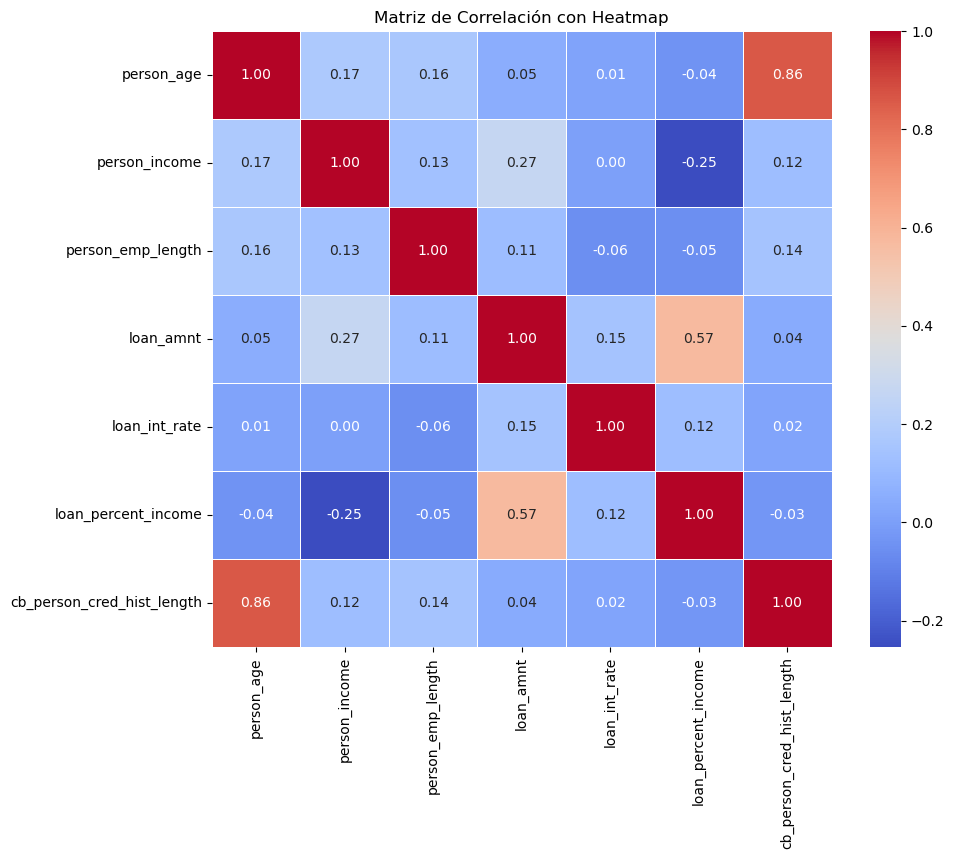

In [10]:
# Numérica vs Numérica
matriz_corr = df_numerical.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación con Heatmap")
plt.show()

xxxx

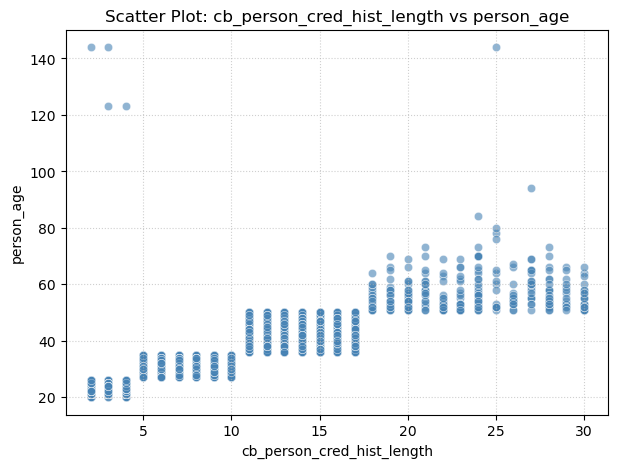

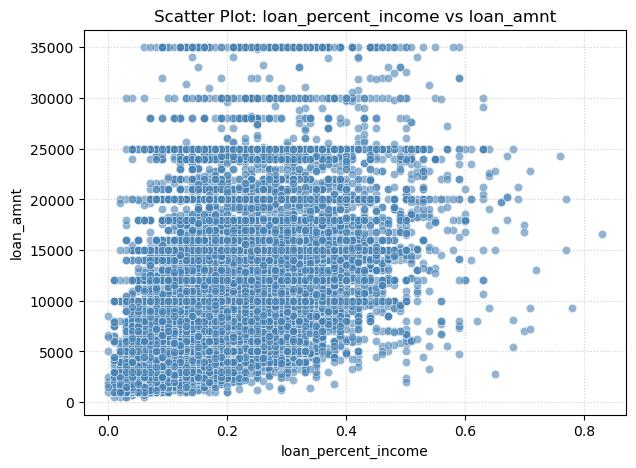

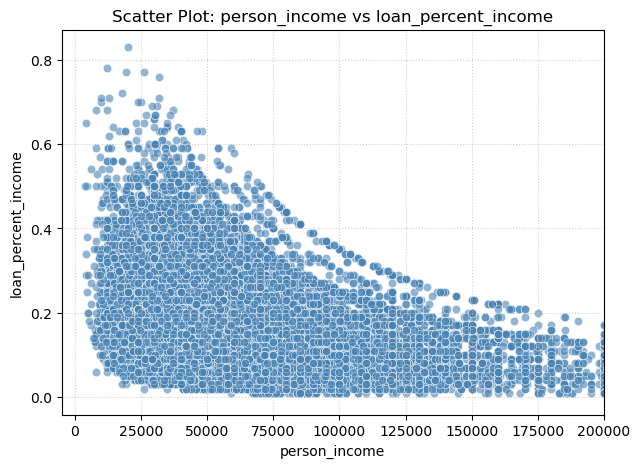

In [13]:
# Relacionas más interesantes
relaciones_nvsn= [
    ('cb_person_cred_hist_length', 'person_age'), # Tupla 1
    ('loan_percent_income', 'loan_amnt'), # Tupla 2
    ('person_income','loan_percent_income') # Tupla 3
]

for x_col, y_col in relaciones_nvsn:
    
    plt.figure(figsize=(7, 5))
    
    # Filtro para ignorar outliers extremos y mejorar la visualización
    if 'person_income' in (x_col, y_col):
        plt.xlim(-5000, 200000)

    # Scatter plot
    sns.scatterplot(data=df_numerical, x=x_col, y=y_col, alpha=0.6, color='steelblue')
    plt.title(f'Scatter Plot: {x_col} vs {y_col}')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.grid(True, linestyle=':', alpha=0.6)
    
    plt.show()

xxxx

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22264\562057193.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


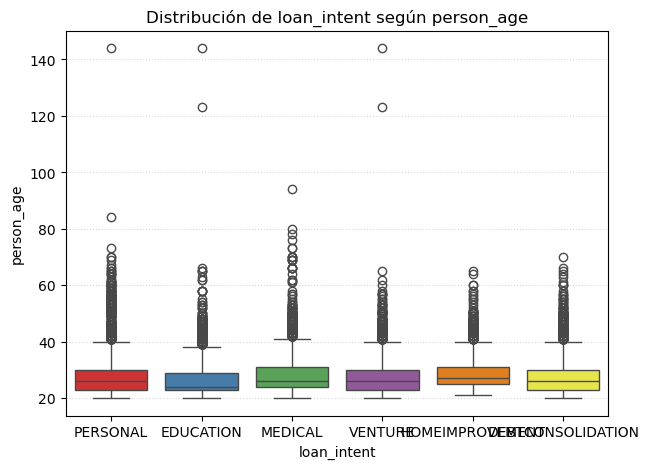

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22264\562057193.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


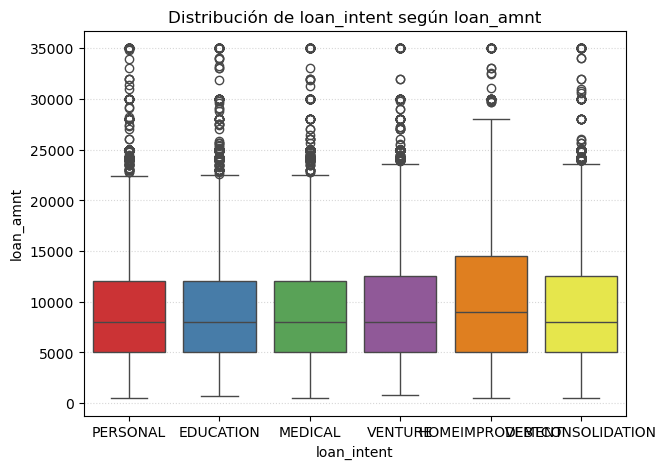

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22264\562057193.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


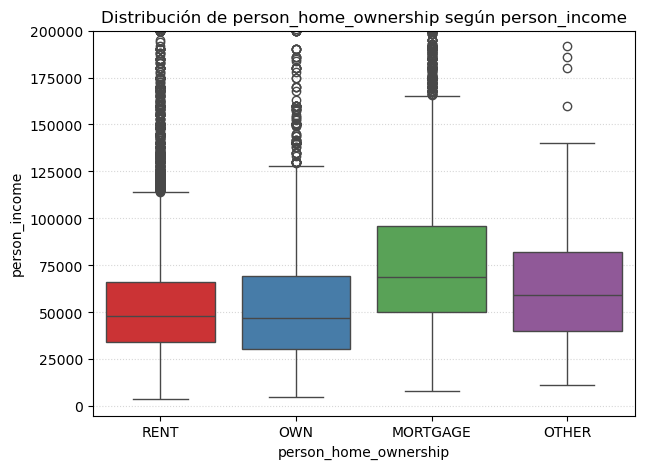

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22264\562057193.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


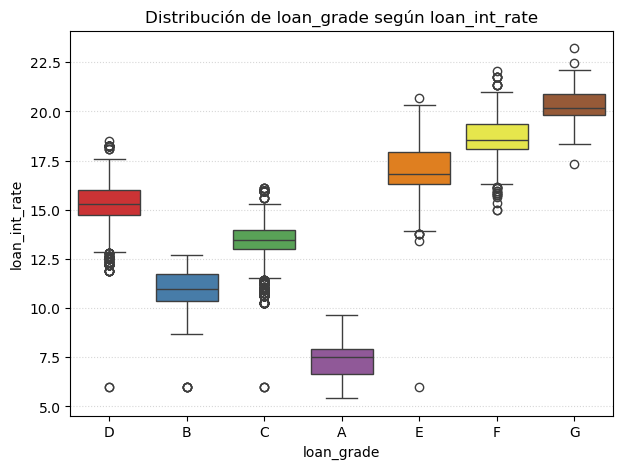

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22264\562057193.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


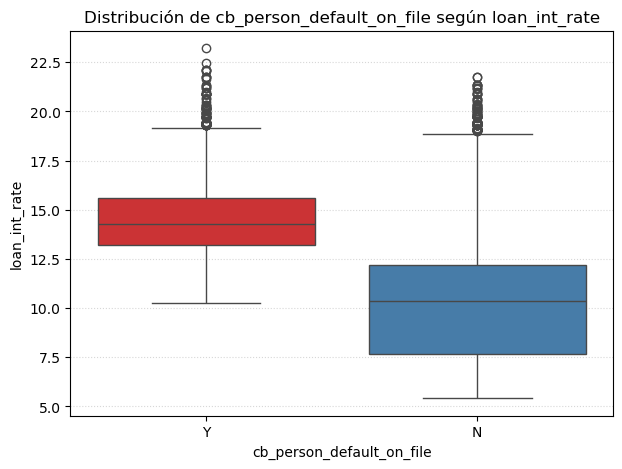

In [ ]:
# Categórica vs Numérica

relaciones_cvsn= [
    ('loan_intent', 'person_age'),
    ('loan_intent', 'loan_amnt'),
    ('person_home_ownership','person_income'),
    ('loan_grade','loan_int_rate'),
    ('cb_person_default_on_file','loan_int_rate')
]

for x_col, y_col in relaciones_cvsn:
    
    plt.figure(figsize=(7, 5))
    
    sns.boxplot(
    data=df, 
    x=x_col,
    y=y_col,
    palette='Set1'
    )
    
    # Filtro para ignorar outliers extremos y mejorar la visualización
    if 'person_income' in (x_col, y_col):
        plt.ylim(-5000, 200000)

    plt.title(f'Distribución de {x_col} según {y_col}')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.grid(axis='y', linestyle=':', alpha=0.5)

    plt.show()

xxxx

TABLA DE CONTINGENCIA: loan_intent vs person_home_ownership
person_home_ownership  MORTGAGE  OTHER  OWN  RENT
loan_intent                                      
DEBTCONSOLIDATION          2312     17   72  2811
EDUCATION                  2627     17  528  3281
HOMEIMPROVEMENT            1741     12  318  1534
MEDICAL                    2190     17  434  3430
PERSONAL                   2340     18  446  2717
VENTURE                    2234     26  786  2673


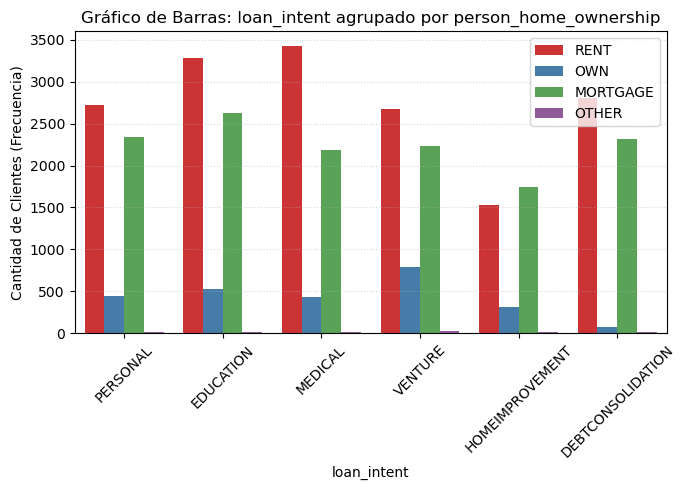

TABLA DE CONTINGENCIA: loan_grade vs cb_person_default_on_file
cb_person_default_on_file      N     Y
loan_grade                            
A                          10777     0
B                          10451     0
C                           3202  3256
D                           1750  1876
E                            499   465
F                            129   112
G                             28    36


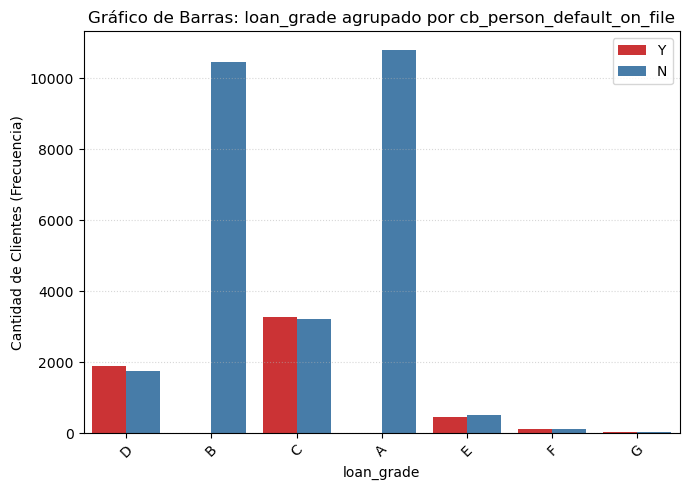

TABLA DE CONTINGENCIA: loan_grade vs loan_status
loan_status     0     1
loan_grade             
A            9704  1073
B            8750  1701
C            5119  1339
D            1485  2141
E             343   621
F              71   170
G               1    63


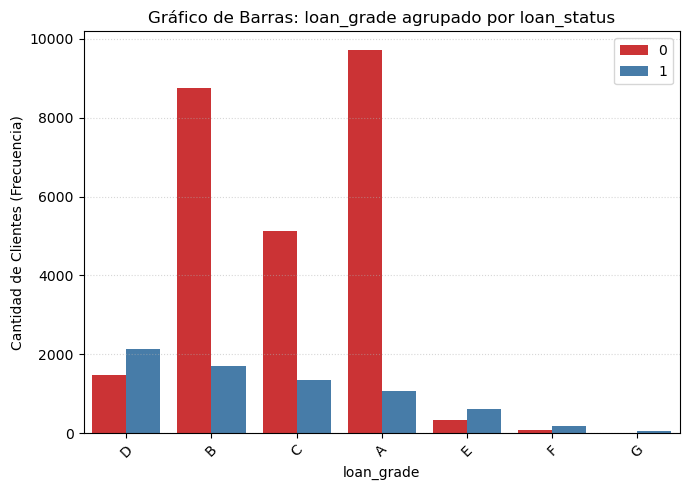

TABLA DE CONTINGENCIA: person_home_ownership vs loan_status
loan_status                0     1
person_home_ownership             
MORTGAGE               11754  1690
OTHER                     74    33
OWN                     2391   193
RENT                   11254  5192


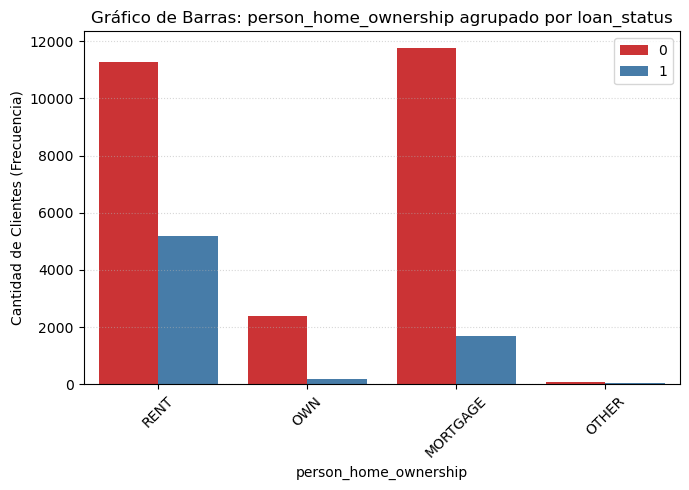

In [ ]:
# Categórica vs Categórica

relaciones_cvsc = [
    ('loan_intent', 'person_home_ownership'),  
    ('loan_grade', 'cb_person_default_on_file'),            
    ('loan_grade', 'loan_status'),
    ('person_home_ownership','loan_status')
]

for x_col, hue_col in relaciones_cvsc:
    
    print(f"TABLA DE CONTINGENCIA: {x_col} vs {hue_col}")
    tabla_contingencia = pd.crosstab(df[x_col], df[hue_col])
    print(tabla_contingencia)
    
    plt.figure(figsize=(7, 5))
    
    # sns.countplot cuenta los registros automáticamente
    sns.countplot(
        data=df,
        x=x_col,
        hue=hue_col,
        palette='Set1'
    )
    
    plt.title(f'Gráfico de Barras: {x_col} agrupado por {hue_col}')
    plt.xlabel(x_col)
    plt.ylabel('Cantidad de Clientes (Frecuencia)')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.legend()
    plt.tight_layout()

    plt.show()

xxxx

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22264\3904570510.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


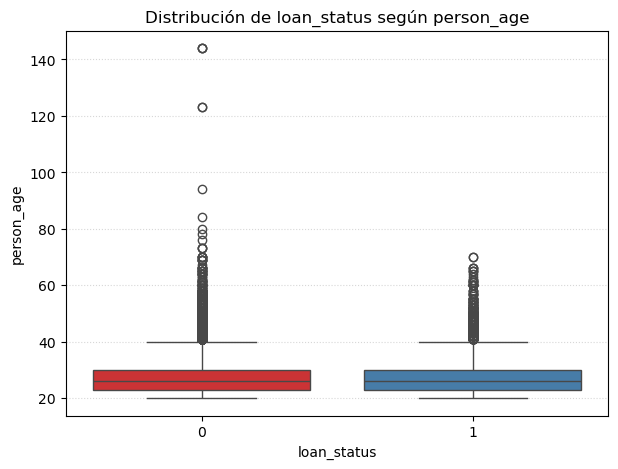

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22264\3904570510.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


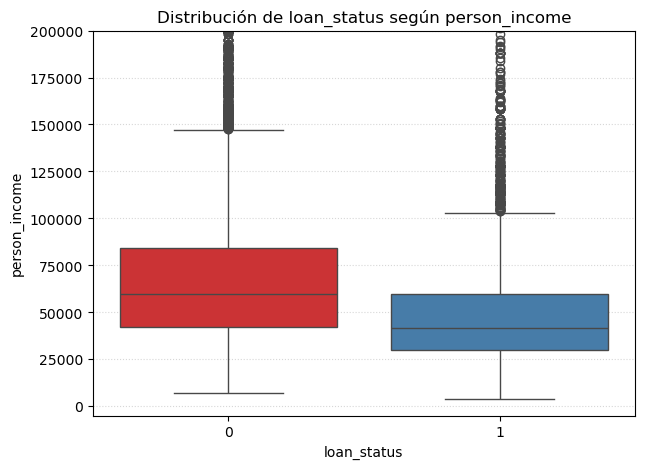

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22264\3904570510.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


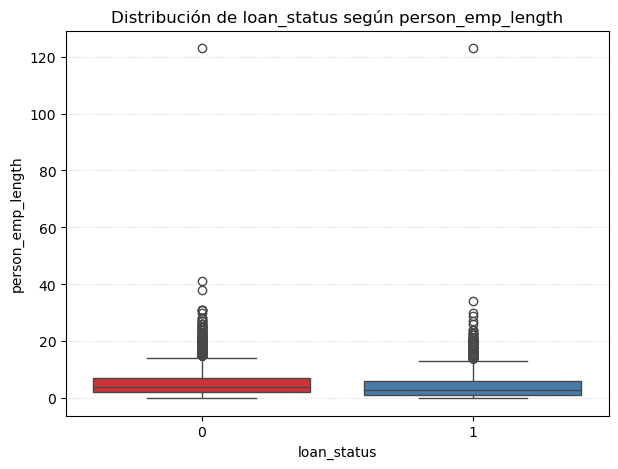

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22264\3904570510.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


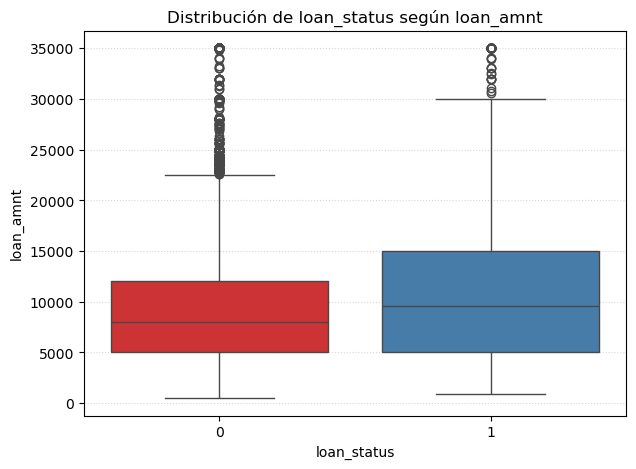

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22264\3904570510.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


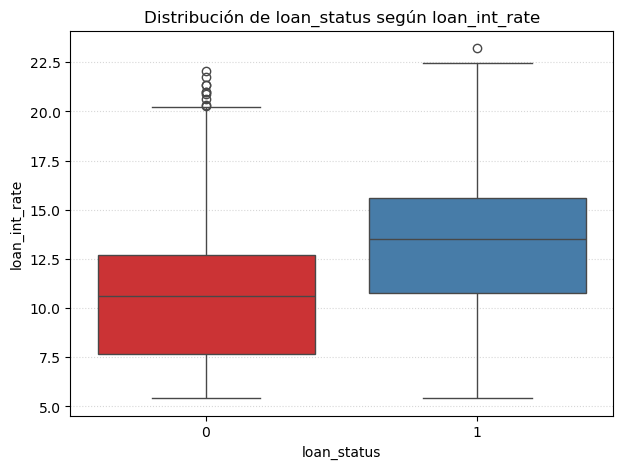

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22264\3904570510.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


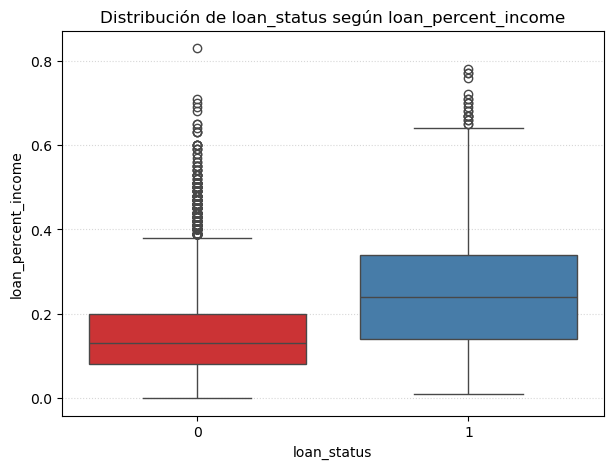

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_22264\3904570510.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


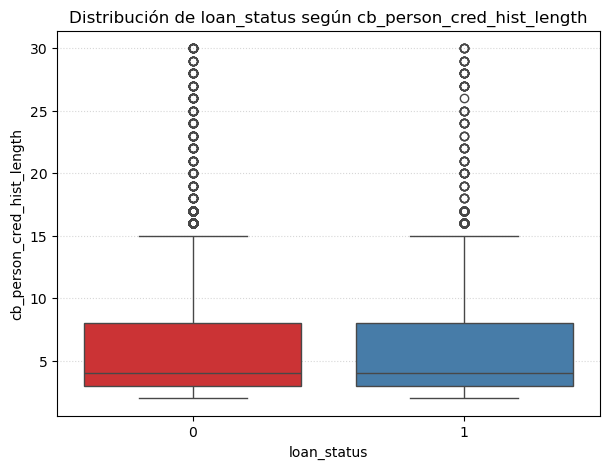

In [ ]:
# Variable objetivo vs numéricas

relaciones_num_target = []

for col in df_numerical.columns:
    relaciones_num_target.append(('loan_status',col))

for x_col, y_col in relaciones_num_target:
    
    plt.figure(figsize=(7, 5))
    
    sns.boxplot(
    data=df,
    x=x_col,
    y=y_col,
    palette='Set1'
    )
    
    # No consideramos al millonario
    if 'person_income' in (x_col, y_col):
        plt.ylim(-5000, 200000)

    plt.title(f'Distribución de {x_col} según {y_col}')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.grid(axis='y', linestyle=':', alpha=0.5)

    plt.show()

xxxx

TABLA DE CONTINGENCIA: loan_status vs person_home_ownership
loan_status                0      1
person_home_ownership              
MORTGAGE               87.43  12.57
OTHER                  69.16  30.84
OWN                    92.53   7.47
RENT                   68.43  31.57


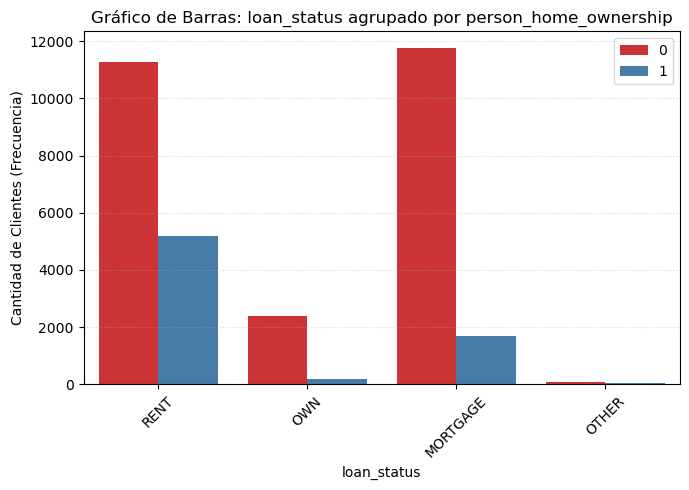

TABLA DE CONTINGENCIA: loan_status vs loan_intent
loan_status            0      1
loan_intent                    
DEBTCONSOLIDATION  71.41  28.59
EDUCATION          82.78  17.22
HOMEIMPROVEMENT    73.90  26.10
MEDICAL            73.30  26.70
PERSONAL           80.11  19.89
VENTURE            85.19  14.81


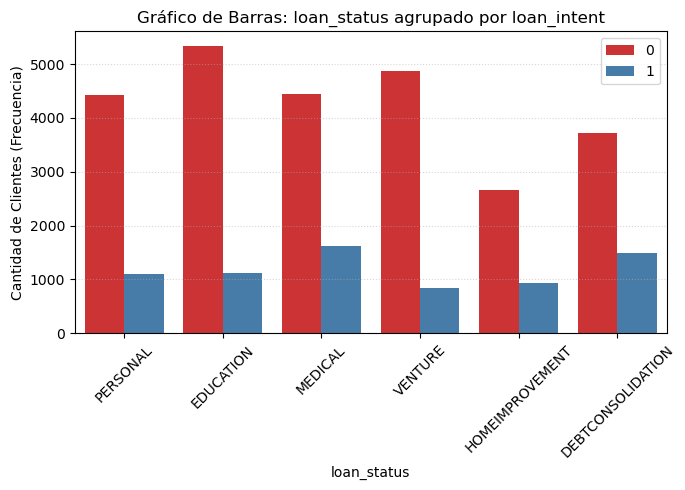

TABLA DE CONTINGENCIA: loan_status vs loan_grade
loan_status      0      1
loan_grade               
A            90.04   9.96
B            83.72  16.28
C            79.27  20.73
D            40.95  59.05
E            35.58  64.42
F            29.46  70.54
G             1.56  98.44


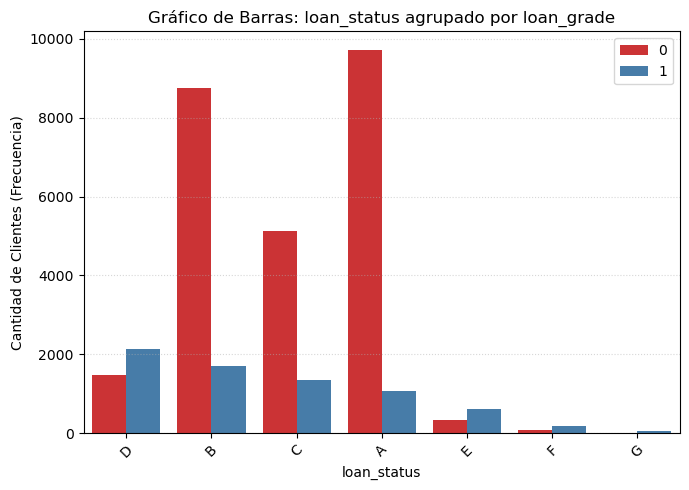

TABLA DE CONTINGENCIA: loan_status vs cb_person_default_on_file
loan_status                    0      1
cb_person_default_on_file              
N                          81.61  18.39
Y                          62.19  37.81


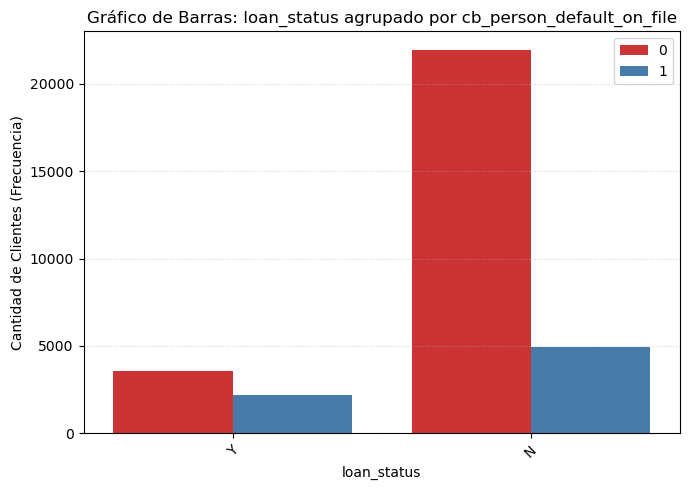

In [ ]:
# Variable objetivo vs categoricas

relaciones_cat_target = []
for col in df_categorical:
    if col != 'loan_status':
        relaciones_cat_target.append(('loan_status',col))

for x_col, hue_col in relaciones_cat_target:
    
    print(f"TABLA DE CONTINGENCIA: {x_col} vs {hue_col}")
    tabla_contingencia = pd.crosstab(df[hue_col], df[x_col], normalize='index')*100
    print(tabla_contingencia.round(2))
    
    plt.figure(figsize=(7, 5))
    
    # sns.countplot cuenta los registros automáticamente
    sns.countplot(
        data=df,
        x=hue_col,
        hue=x_col,
        palette='Set1'
    )
    
    plt.title(f'Gráfico de Barras: {x_col} agrupado por {hue_col}')
    plt.xlabel(x_col)
    plt.ylabel('Cantidad de Clientes (Frecuencia)')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.legend()
    plt.tight_layout()

    plt.show()

xxxx